# Modeling — Phase 5
Three models: TF-IDF+LinearSVC, FastText, SentenceTransformers.
Run all cells top to bottom. Paste back Cell 8 output only.

In [1]:
# CELL 1 — Load data
import pandas as pd
import joblib
import numpy as np
import warnings
warnings.filterwarnings('ignore')

PROJ = '/home/tayana-gpu/ML/project_01_product_classifier'

train_df = pd.read_parquet(f'{PROJ}/data/train.parquet')
test_df  = pd.read_parquet(f'{PROJ}/data/test.parquet')
le       = joblib.load(f'{PROJ}/models/label_encoder.pkl')

X_train = train_df['text'].tolist()
y_train = train_df['label'].tolist()
X_test  = test_df['text'].tolist()
y_test  = test_df['label'].tolist()

print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Classes ({len(le.classes_)}): {le.classes_.tolist()}')

Train: 72,940  |  Test: 18,235
Classes (12): ['Animals and Birds and Fish', 'Apparel and Luggage and Personal Care Products', 'Audio and Visual Presentation and Composing Equipment', 'Building and Construction Machinery and Accessories', 'Domestic Appliances and Supplies and Consumer Electronic Products', 'Electronic Components and Supplies', 'Industrial Machinery and Equipment', 'Information Technology Broadcasting and Telecommunications', 'Office Equipment and Accessories and Supplies', 'Pharmaceuticals and Healthcare Products', 'Sports and Recreational Equipment and Supplies', 'Transportation and Storage and Mail Services']


In [2]:
# CELL 2 — Model 1: TF-IDF + LinearSVC
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import f1_score, classification_report
import time

word_vec = TfidfVectorizer(
    analyzer='word', ngram_range=(1, 2),
    min_df=5, max_features=200000,
    sublinear_tf=True
)
char_vec = TfidfVectorizer(
    analyzer='char_wb', ngram_range=(3, 5),
    min_df=5, max_features=200000,
    sublinear_tf=True
)

pipeline_svc = Pipeline([
    ('features', FeatureUnion([('word', word_vec), ('char', char_vec)])),
    ('clf', LinearSVC(class_weight='balanced', max_iter=2000, C=1.0))
])

t0 = time.time()
print('Training LinearSVC...')
pipeline_svc.fit(X_train, y_train)
y_pred_svc = pipeline_svc.predict(X_test)
t1 = time.time()

svc_macro = f1_score(y_test, y_pred_svc, average='macro')
svc_weighted = f1_score(y_test, y_pred_svc, average='weighted')
print(f'Done in {t1-t0:.0f}s')
print(f'LinearSVC  Macro F1: {svc_macro:.4f}  |  Weighted F1: {svc_weighted:.4f}')
print()
print(classification_report(y_test, y_pred_svc, target_names=le.classes_))

joblib.dump(pipeline_svc, f'{PROJ}/models/model_svc.pkl')
print('Saved models/model_svc.pkl')

Training LinearSVC...
Done in 68s
LinearSVC  Macro F1: 0.8469  |  Weighted F1: 0.9003

                                                                   precision    recall  f1-score   support

                                       Animals and Birds and Fish       0.89      0.93      0.91       375
                   Apparel and Luggage and Personal Care Products       0.97      0.97      0.97      7363
            Audio and Visual Presentation and Composing Equipment       0.95      0.93      0.94       370
              Building and Construction Machinery and Accessories       0.80      0.80      0.80      1580
Domestic Appliances and Supplies and Consumer Electronic Products       0.87      0.89      0.88      2819
                               Electronic Components and Supplies       0.92      0.94      0.93      1893
                               Industrial Machinery and Equipment       0.67      0.57      0.62       489
       Information Technology Broadcasting and Telecommu

In [3]:
# CELL 3 — Model 2: FastText
import fasttext
import tempfile, os, time
from sklearn.metrics import f1_score, classification_report

def write_ft_file(texts, labels, path, le):
    with open(path, 'w', encoding='utf-8') as f:
        for text, label in zip(texts, labels):
            label_str = le.classes_[label].replace(' ', '_')
            f.write(f'__label__{label_str} {text}\n')

train_ft = f'{PROJ}/data/train_ft.txt'
test_ft  = f'{PROJ}/data/test_ft.txt'
write_ft_file(X_train, y_train, train_ft, le)
write_ft_file(X_test,  y_test,  test_ft,  le)
print('FastText data files written.')

t0 = time.time()
print('Training FastText...')
ft_model = fasttext.train_supervised(
    input=train_ft,
    lr=0.5, epoch=25, wordNgrams=2,
    dim=100, minCount=5,
    loss='softmax', thread=8
)
t1 = time.time()
print(f'Done in {t1-t0:.0f}s')

result = ft_model.test(test_ft)
print(f'FastText samples={result[0]}  P={result[1]:.4f}  R={result[2]:.4f}')

ft_preds  = [ft_model.predict(t)[0][0].replace('__label__','').replace('_',' ') for t in X_test]
ft_true   = [le.classes_[l] for l in y_test]
ft_macro  = f1_score(ft_true, ft_preds, average='macro')
ft_weighted = f1_score(ft_true, ft_preds, average='weighted')
print(f'FastText   Macro F1: {ft_macro:.4f}  |  Weighted F1: {ft_weighted:.4f}')
print()
print(classification_report(ft_true, ft_preds))

ft_model.save_model(f'{PROJ}/models/model_fasttext.bin')
print('Saved models/model_fasttext.bin')

FastText data files written.
Training FastText...


Read 9M words
Number of words:  48898
Number of labels: 12
Progress: 100.0% words/sec/thread: 2882200 lr:  0.000000 avg.loss:  0.070047 ETA:   0h 0m 0s


Done in 11s
FastText samples=18235  P=0.8900  R=0.8900
FastText   Macro F1: 0.8301  |  Weighted F1: 0.8884

                                                                   precision    recall  f1-score   support

                                       Animals and Birds and Fish       0.91      0.89      0.90       375
                   Apparel and Luggage and Personal Care Products       0.95      0.97      0.96      7363
            Audio and Visual Presentation and Composing Equipment       0.93      0.89      0.91       370
              Building and Construction Machinery and Accessories       0.79      0.78      0.78      1580
Domestic Appliances and Supplies and Consumer Electronic Products       0.86      0.88      0.87      2819
                               Electronic Components and Supplies       0.91      0.93      0.92      1893
                               Industrial Machinery and Equipment       0.64      0.53      0.58       489
       Information Technology Broad

In [4]:
# CELL 4 — Model 3: SentenceTransformers semantic search
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import f1_score, classification_report
import numpy as np, json, time

# Descriptions for each of our 12 segments
SEGMENT_DESCRIPTIONS = {
    'Animals and Birds and Fish':
        'pet supplies dog cat fish bird animal food treats toys leash collar aquarium',
    'Apparel and Luggage and Personal Care Products':
        'clothing fashion apparel shoes boots sneakers shirts pants dress jacket luggage bags accessories jewelry handbag wallet',
    'Audio and Visual Presentation and Composing Equipment':
        'music audio video headphones speakers microphone guitar piano drums violin instrument CD vinyl digital music',
    'Building and Construction Machinery and Accessories':
        'tools hardware drill saw screwdriver wrench plumbing electrical wiring home improvement construction building repair',
    'Domestic Appliances and Supplies and Consumer Electronic Products':
        'home appliances kitchen cookware bedding furniture vacuum cleaner home decor storage organizer lamp curtain',
    'Electronic Components and Supplies':
        'electronics phone smartphone laptop computer tablet camera charger cable USB battery circuit board semiconductor',
    'Industrial Machinery and Equipment':
        'industrial machinery manufacturing equipment pump motor compressor valve bearing gear factory automation',
    'Information Technology Broadcasting and Telecommunications':
        'software app application android iOS mobile operating system programming computing cloud network telecommunications',
    'Office Equipment and Accessories and Supplies':
        'office supplies stationery pen paper notebook printer ink toner folder binder craft sewing art supplies',
    'Pharmaceuticals and Healthcare Products':
        'health medicine supplement vitamin pharmacy personal care beauty skincare cosmetics baby hygiene wellness',
    'Sports and Recreational Equipment and Supplies':
        'sports fitness outdoor recreation exercise gym yoga running cycling hiking camping toys games',
    'Transportation and Storage and Mail Services':
        'automotive car vehicle truck motorcycle parts accessories oil filter brake tire wheel GPS dashboard',
}

segment_names = list(SEGMENT_DESCRIPTIONS.keys())
segment_descs = list(SEGMENT_DESCRIPTIONS.values())

print('Loading SentenceTransformer model...')
st_model = SentenceTransformer('all-MiniLM-L6-v2')

print('Encoding UNSPSC segment anchors...')
seg_embeddings = st_model.encode(segment_descs, batch_size=32, show_progress_bar=False)

print('Encoding test products...')
t0 = time.time()
prod_embeddings = st_model.encode(X_test, batch_size=256, show_progress_bar=True)
t1 = time.time()
print(f'Encoded {len(X_test):,} products in {t1-t0:.0f}s')

sims = cosine_similarity(prod_embeddings, seg_embeddings)
pred_idx = np.argmax(sims, axis=1)
st_preds = [segment_names[i] for i in pred_idx]
st_true  = [le.classes_[l] for l in y_test]

st_macro   = f1_score(st_true, st_preds, average='macro')
st_weighted = f1_score(st_true, st_preds, average='weighted')
print(f'SentTrans  Macro F1: {st_macro:.4f}  |  Weighted F1: {st_weighted:.4f}')
print()
print(classification_report(st_true, st_preds))

np.save(f'{PROJ}/models/segment_embeddings.npy', seg_embeddings)
with open(f'{PROJ}/models/segment_names.json', 'w') as f:
    json.dump(segment_names, f)
print('Saved models/segment_embeddings.npy, models/segment_names.json')

Loading SentenceTransformer model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding UNSPSC segment anchors...
Encoding test products...


Batches:   0%|          | 0/72 [00:00<?, ?it/s]

Encoded 18,235 products in 10s
SentTrans  Macro F1: 0.4474  |  Weighted F1: 0.6250

                                                                   precision    recall  f1-score   support

                                       Animals and Birds and Fish       0.45      0.86      0.59       375
                   Apparel and Luggage and Personal Care Products       0.86      0.82      0.84      7363
            Audio and Visual Presentation and Composing Equipment       0.44      0.70      0.54       370
              Building and Construction Machinery and Accessories       0.44      0.19      0.27      1580
Domestic Appliances and Supplies and Consumer Electronic Products       0.56      0.52      0.54      2819
                               Electronic Components and Supplies       0.80      0.51      0.62      1893
                               Industrial Machinery and Equipment       0.17      0.09      0.12       489
       Information Technology Broadcasting and Telecommunic

In [5]:
# CELL 5 — Model comparison + pick best
results = {
    'LinearSVC (TF-IDF word+char n-grams)':      svc_macro,
    'FastText (subword embeddings)':              ft_macro,
    'SentenceTransformers (semantic search)':     st_macro,
}

print('=== MODEL COMPARISON (Macro F1 on test set) ===')
for name, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f'  {name:<45} {score:.4f}')

best_name  = max(results, key=results.get)
best_score = results[best_name]
print(f'\nBest model: {best_name}  (Macro F1 = {best_score:.4f})')

# Also print weighted F1 for reference
print(f'\nWeighted F1:')
print(f'  LinearSVC:           {svc_weighted:.4f}')
print(f'  FastText:            {ft_weighted:.4f}')
print(f'  SentenceTransformers: {st_weighted:.4f}')

=== MODEL COMPARISON (Macro F1 on test set) ===
  LinearSVC (TF-IDF word+char n-grams)          0.8469
  FastText (subword embeddings)                 0.8301
  SentenceTransformers (semantic search)        0.4474

Best model: LinearSVC (TF-IDF word+char n-grams)  (Macro F1 = 0.8469)

Weighted F1:
  LinearSVC:           0.9003
  FastText:            0.8884
  SentenceTransformers: 0.6250


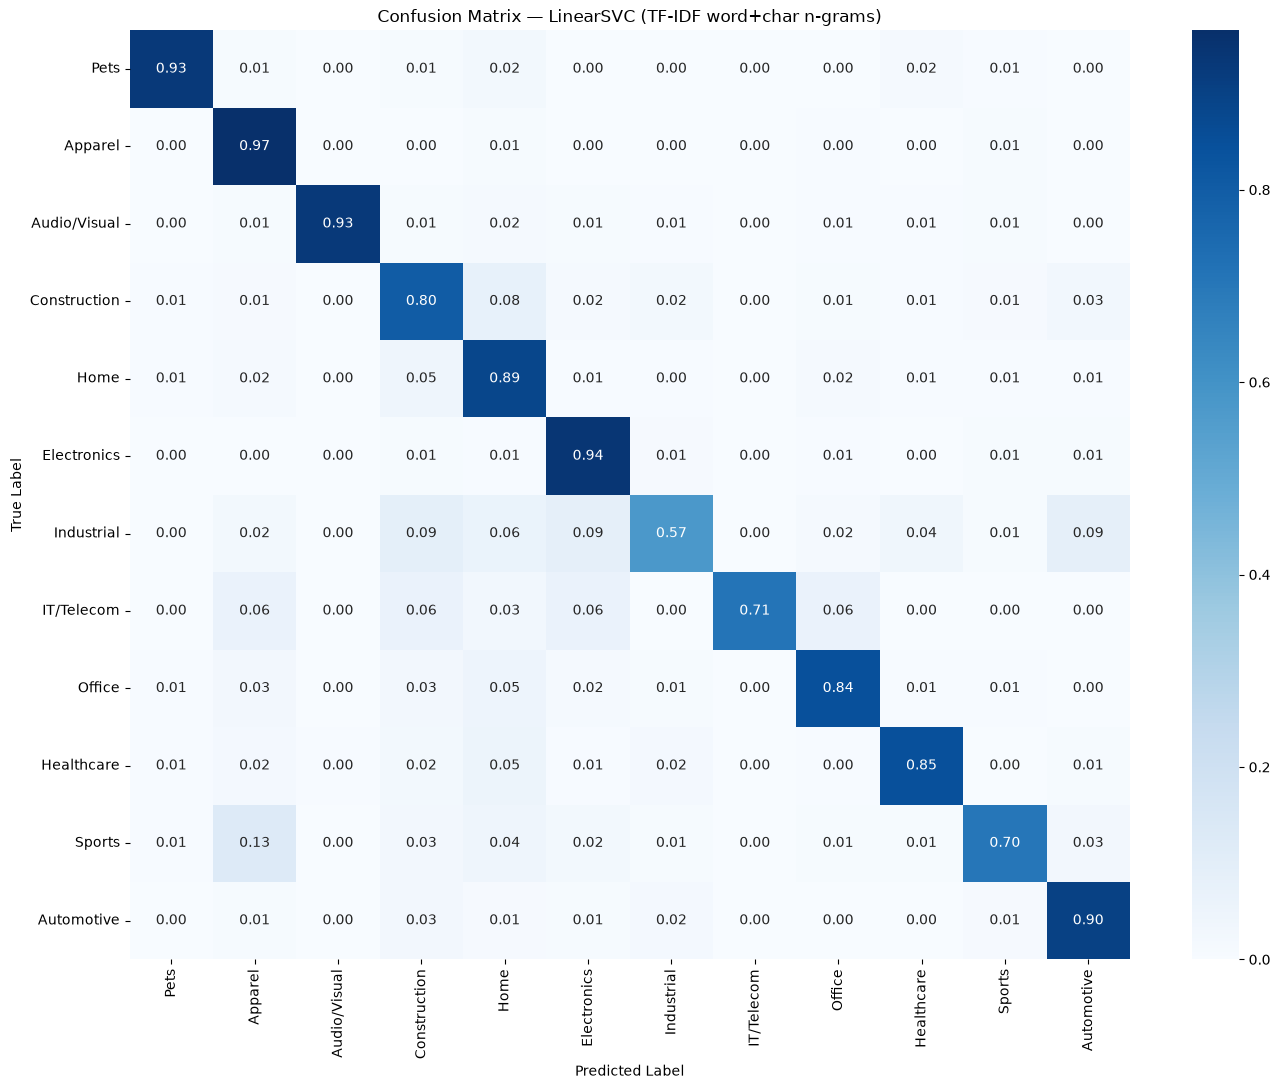

Saved figures/confusion_matrix.png


In [6]:
# CELL 6 — Confusion matrix for best model
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import os

os.makedirs(f'{PROJ}/figures', exist_ok=True)

SHORT = [
    'Pets', 'Apparel', 'Audio/Visual', 'Construction',
    'Home', 'Electronics', 'Industrial', 'IT/Telecom',
    'Office', 'Healthcare', 'Sports', 'Automotive'
]

# Pick best model predictions
if best_name.startswith('LinearSVC'):
    best_preds_str = [le.classes_[p] for p in y_pred_svc]
elif best_name.startswith('FastText'):
    best_preds_str = ft_preds
else:
    best_preds_str = st_preds

true_str = [le.classes_[l] for l in y_test]
cm = confusion_matrix(true_str, best_preds_str, labels=le.classes_)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(14, 11))
sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=SHORT, yticklabels=SHORT)
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f'{PROJ}/figures/confusion_matrix.png', dpi=150)
plt.show()
print('Saved figures/confusion_matrix.png')

In [7]:
# CELL 7 — Error analysis for best model
from sklearn.metrics import classification_report
import pandas as pd

error_df = test_df.copy()
error_df['true_label']  = true_str
error_df['predicted']   = best_preds_str
error_df['correct']     = error_df['true_label'] == error_df['predicted']

print(f'Overall accuracy: {error_df["correct"].mean()*100:.1f}%')
print(f'Total errors: {(~error_df["correct"]).sum():,} out of {len(error_df):,}')

errors = error_df[~error_df['correct']]
pair_counts = errors.groupby(['true_label','predicted']).size().sort_values(ascending=False)
print(f'\nTop 10 misclassification pairs (True → Predicted):')
print(pair_counts.head(10).to_string())

# Sample 3 errors from top confused pair
if len(pair_counts) > 0:
    top_true, top_pred = pair_counts.index[0]
    samples = errors[(errors['true_label']==top_true) & (errors['predicted']==top_pred)]['text'].head(3)
    print(f'\nSample errors: true="{top_true[:30]}" predicted="{top_pred[:30]}"')
    for s in samples:
        print(f'  → {s[:120]}')

Overall accuracy: 90.1%
Total errors: 1,805 out of 18,235

Top 10 misclassification pairs (True → Predicted):
true_label                                                         predicted                                                        
Domestic Appliances and Supplies and Consumer Electronic Products  Building and Construction Machinery and Accessories                  128
Building and Construction Machinery and Accessories                Domestic Appliances and Supplies and Consumer Electronic Products    123
Sports and Recreational Equipment and Supplies                     Apparel and Luggage and Personal Care Products                        82
Apparel and Luggage and Personal Care Products                     Sports and Recreational Equipment and Supplies                        73
                                                                   Domestic Appliances and Supplies and Consumer Electronic Products     69
Building and Construction Machinery and Accessories      

In [8]:
# CELL 8 — Final evaluation report (PASTE THIS OUTPUT BACK)
from sklearn.metrics import classification_report
import os

os.makedirs(f'{PROJ}/evaluation', exist_ok=True)

report = classification_report(true_str, best_preds_str,
                                labels=le.classes_.tolist(),
                                output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df.to_csv(f'{PROJ}/evaluation/classification_report.csv')

class_f1 = {k: v['f1-score'] for k, v in report.items() if k in le.classes_}

print('=== FINAL REPORT ===')
print(f'Best Model:   {best_name}')
print(f'Macro F1:     {report["macro avg"]["f1-score"]:.4f}')
print(f'Weighted F1:  {report["weighted avg"]["f1-score"]:.4f}')
print(f'Accuracy:     {report["accuracy"]:.4f}')
print(f'\nAll model scores:')
print(f'  LinearSVC:            Macro F1 = {svc_macro:.4f}')
print(f'  FastText:             Macro F1 = {ft_macro:.4f}')
print(f'  SentenceTransformers: Macro F1 = {st_macro:.4f}')
print(f'\nPer-class F1 (sorted worst → best):')
for cls, f1 in sorted(class_f1.items(), key=lambda x: x[1]):
    print(f'  {cls:<60} {f1:.4f}')
print(f'\nSaved evaluation/classification_report.csv')

=== FINAL REPORT ===
Best Model:   LinearSVC (TF-IDF word+char n-grams)
Macro F1:     0.8469
Weighted F1:  0.9003
Accuracy:     0.9010

All model scores:
  LinearSVC:            Macro F1 = 0.8469
  FastText:             Macro F1 = 0.8301
  SentenceTransformers: Macro F1 = 0.4474

Per-class F1 (sorted worst → best):
  Industrial Machinery and Equipment                           0.6183
  Sports and Recreational Equipment and Supplies               0.7252
  Building and Construction Machinery and Accessories          0.8000
  Information Technology Broadcasting and Telecommunications   0.8148
  Office Equipment and Accessories and Supplies                0.8434
  Pharmaceuticals and Healthcare Products                      0.8509
  Domestic Appliances and Supplies and Consumer Electronic Products 0.8781
  Transportation and Storage and Mail Services                 0.8844
  Animals and Birds and Fish                                   0.9089
  Electronic Components and Supplies            